In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from tqdm import tqdm

# Inställningar
%matplotlib inline
sns.set_theme(style="whitegrid")
tqdm.pandas()


analyzer = SentimentIntensityAnalyzer()
model_name = 'nlptown/bert-base-multilingual-uncased-sentiment'
nlp_worker = pipeline('sentiment-analysis', model=model_name)

# Funktioner
def calculate_vader(text):
    return analyzer.polarity_scores(str(text))['compound']

def calculate_bert(text):
    result = nlp_worker(str(text)[:512])[0]
    stars = int(result['label'].split()[0])
    return 1 if stars >= 4 else -1


df = pd.read_csv('dataset.csv', nrows=50000)
df_clean = df[['review_text', 'review_score']].dropna(subset=['review_text']).drop_duplicates()

print("Data laddad och städad!")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7868.58it/s]


Data laddad och städad!


In [26]:
df_pos = df_clean[df_clean['review_score'] == 1].sample(500, random_state=42)
df_neg = df_clean[df_clean['review_score'] == -1].sample(500, random_state=42)
df_vader = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).copy()

print("Analyserar med VADER...")
df_vader['vader_compound'] = df_vader['review_text'].progress_apply(calculate_vader)
df_vader['vader_pred'] = df_vader['vader_compound'].apply(lambda x: 1 if x >= 0.05 else -1)

v_acc = (df_vader['vader_pred'] == df_vader['review_score']).mean()
print(f"VADER Accuracy: {v_acc:.2%}")

Analyserar med VADER...


100%|██████████| 1000/1000 [00:00<00:00, 1976.51it/s]


VADER Accuracy: 63.50%


In [27]:
df_pos_b = df_clean[df_clean['review_score'] == 1].sample(500, random_state=42)
df_neg_b = df_clean[df_clean['review_score'] == -1].sample(500, random_state=42)
df_bert = pd.concat([df_pos_b, df_neg_b]).sample(frac=1, random_state=42).copy()

print("Analyserar med BERT...")
df_bert['bert_pred'] = df_bert['review_text'].progress_apply(calculate_bert)

b_acc = (df_bert['bert_pred'] == df_bert['review_score']).mean()
print(f"BERT Accuracy: {b_acc:.2%}")

Analyserar med BERT...


100%|██████████| 1000/1000 [00:58<00:00, 17.06it/s]

BERT Accuracy: 81.10%


C:\Users\Administrator\AppData\Local\Temp\ipykernel_20588\2971202546.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=scores, palette='coolwarm')


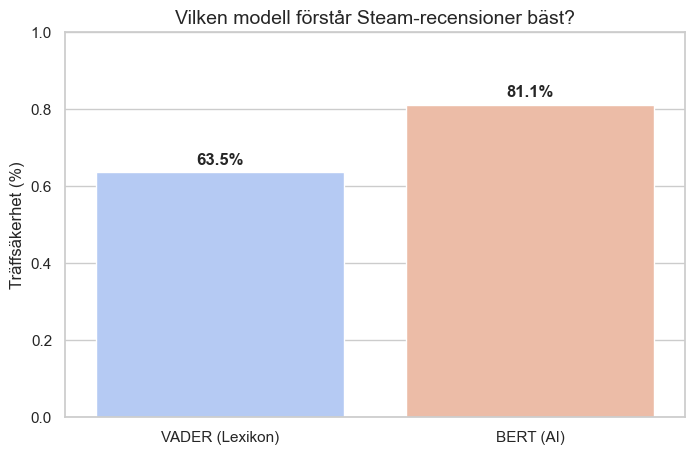

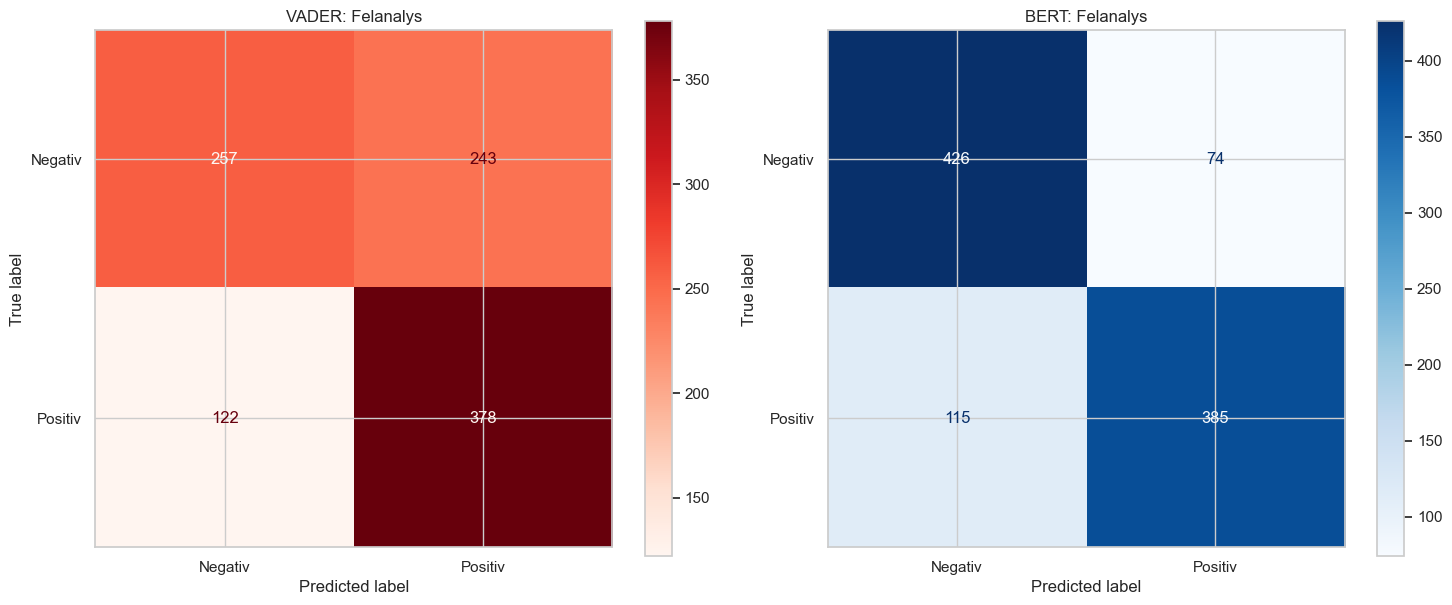

In [28]:
# --- GRAF 1: Jämförelse av Träffsäkerhet ---
plt.figure(figsize=(8, 5))
models = ['VADER (Lexikon)', 'BERT (AI)']
scores = [v_acc, b_acc]

ax = sns.barplot(x=models, y=scores, palette='coolwarm')
plt.title('Vilken modell förstår Steam-recensioner bäst?', fontsize=14)
plt.ylabel('Träffsäkerhet (%)')
plt.ylim(0, 1)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.02), 
                ha='center', fontweight='bold')
plt.show()

# --- GRAF 2: Förväxlingsmatriser (Confusion Matrices) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# VADER
ConfusionMatrixDisplay.from_predictions(
    df_vader['review_score'], df_vader['vader_pred'],
    display_labels=['Negativ', 'Positiv'], cmap='Reds', ax=ax1
)
ax1.set_title('VADER: Felanalys', fontsize=12)

# BERT
ConfusionMatrixDisplay.from_predictions(
    df_bert['review_score'], df_bert['bert_pred'],
    display_labels=['Negativ', 'Positiv'], cmap='Blues', ax=ax2
)
ax2.set_title('BERT: Felanalys', fontsize=12)

plt.tight_layout()
plt.show()

In [29]:
pd.set_option('display.max_colwidth', None)

bert_fails = df_bert[(df_bert['review_score'] == 1) & (df_bert['bert_pred'] == -1) & (df_bert['review_text'].str.len() > 60)]

if not bert_fails.empty:
    print("BERT FEL (Slumpade):")
    display(bert_fails[['review_text', 'review_score', 'bert_pred']].sample(min(len(bert_fails), 10)))

vader_fails = df_vader[(df_vader['review_score'] == 1) & (df_vader['vader_pred'] == -1) & (df_vader['review_text'].str.len() > 40)]

if not vader_fails.empty:
    print("\nVADER FEL (Slumpade):")
    display(vader_fails[['review_text', 'review_score', 'vader_pred']].sample(min(len(vader_fails), 10)))

BERT FEL (Slumpade):


,review_text,review_score,bert_pred
8369,"This game played a huge role in my childhood :D Still the best fps for competitive play, but unfortunately steam ruined this game with the latest updates :(",1,-1
23384,"Sort of ridiculous, sort of ridiculously fun. Lots of criticisms comparing it to Infamous and other games. Really, it's a good sandbox super powered game with villains, conspiracies, biowarfare, and an amoral inhuman protagonist. I've had a ridiculous amount of fun with it anyway. The only caveat is the end-boss is ridiculously unenjoyable.",1,-1
41112,it isnt working for me plz change this i want the black rose,1,-1
33015,"It's a pretty average game. The Graphics and world building are top notch. The combat and balancing was unique but not fully engaging. It became monotonous and I just ran past most of the fights towards the end. I suggest this game to people who really like RPGs. If you don't like RPGs, I don't think there's much here you'll enjoy. The story and writing is a bit inconsistent. The sidequests are written brilliantly while the main story is rather dry. The combat isn't bad, but it's not good. It was never balanced properly. So your character will be OP for about 90% of the game no matter what you pick. Combat is more of a pacing mechanic than a meaty gameplay element. You'll find yourself simply running past enemies to fulfill quests since enemies become time sinks rather than challenges. It was the quintessential mediocre RPG. Not too good, not too bad, with proper pacing so you never get stuck doing something you don't want to do.",1,-1
32326,"It's like Puzzlequest with poker! Or if you haven't played that, it's like versus poker!",1,-1
46151,"From the creators of Project Gotham Racing. They bring quite an unorthodox video game. It's a game that your main focus is achieving the highest score rather than progressing through any form of plot. Except the characters' brief backstory, and an ending in the same shortness of earlier fighting games. 8 skilled killers have been taken into an organization called 'The Club'. Whether they wanted to be in it or not. They fight in several tournaments of ultraviolence to reclaim their freedom or what they desire. Each contestant has unique attributes to them. How fast they move, how much damage they can take, and how much damage they dish out. It allows for some experimenting to see who can rack the best chains of kills quick as possible in various events regarding survival, moving through the level at a quick pace, or sustain damage better when health is scarce. If you like score attacking video games, just killing your foes stylishly and quick as possible. This game is for you. If you want plot or deep storyline. Don't expect it in this game. Please note to use the patch fix guide on steam, when you finished installing. Pros: *Can be as very tough or very easy as you want it to be *Art style aged decently for a 2008 game *Good pacing for the action *Decent music *Has a skill ceiling required to get the best scores. AI does their best to disrupt your scores or to overwhelm you. Cons *Multiplayer is probably non existent by now *Could've been at least some more lines for the characters in their endings. I think they deserve to at least say something for killing for their freedom. *May get repetitive for some. 7.5/ 10 Would recommend to anyone who likes arcadey gameplay or third person shooters, and can live without a plot rich storyline.",1,-1
17385,Wait? This game has a campagin? Man I thought it was only zombies...,1,-1
48967,How much fun can you have for 60p? Chased by a T-Rex Picked up by a Ptera Thrown onto a tank Proceed to blow up everything Better than a bag of Walkers 10/10 would scream hysterically again,1,-1
49411,"This game needs better optimization but its good. I wish this game had a better explanation of the gamemodes, and it had more unlocks. The game dinos just seem to be repeating and have very bad sprites.",1,-1
15513,That damn campaign really fo


VADER FEL (Slumpade):


,review_text,review_score,vader_pred
46361,A Digital book witch includes some secrets that havent been told....,1,-1
9641,Get this game! and Counter Strike Condition Zero Also Source!!!!,1,-1
29864,Score 9 / 10 Its MW2 what else can i say?,1,-1
26058,"Modern Warfare 2 was good before the hackers showed up on multiplayer :( SO DON'T PLAY MULTIPLAYER! Single Player: I think the story is good, Sadly the opening is annoying with a Man yelling 'aim down your sights' every 2 f**king seconds, then you do a obstacle course and then after it, you can do the course again to beat the time OR go up the stairs to end the turtorial..depending ON HOW you do the course, They might recommend A certain difficulty BUT don't worry, you pick the difficulty for yourself! The game then starts to bloom and sometimes you wanna gun down everyone AND some...you just feel sorry for! some characters are memorable and you then wanna pick up Modern Warfare 3 by the end JUST so you can see the final chapter of your favorite allies and the aftermath, etc. HONESTLY this game is worth it (Any COD after Black Ops 2 I WOULD IGNORE!) since the story tries to be serious and it turns out funny sometimes WITH some cool easter eggs AND UMMMMM....There's one bad mission You should avoid NOT IN TERMS OF GAMEPLAY, in terms of what you do in the mission LUCKILY the game asks you if you wanna skip the mission (trust me completionests..it wont damage your 100%) ALOT of people blame MW2 for what COD is now... BUT HONESTLY....We just assign blame... This COD Title AND EVERYONE BEFORE BLACK OPS 2 is good... This was the Game that gave COD some thumbs-up and sadly the first one..to get some more hate (pre mw3 wise!) BUT if you can be attached to a character who talks over he radio and says some stuff over and over..you know this is the best infinity ward COD EVER! so..GET IT! p.s. if anyone tells you modern warfare 3 is bad, they hate it because of the multiplayer SOOO..ignore them ok? ok! ALSo ill make a mw3 review when I get it!",1,-1
48350,"Bacon bacon bacon! The announcers blare out as I pick up an item that decreases my skills cooldown, increase my health regeneration, and increase my speed. As I blitz across the arena on my bacon fed Pro, I jump into action to save a healer being snared by the enemy. My three activated skills come off cooldown and I blind the enemy players, charge into them to knock them into my lane's minions and tower. The healer I just saved switches his gun from a healing beam to a life-draining, slowing beam to keep the enemy team in place. The rest of my team comes out of the jungle to turn this 5 vs 1 gank into a multi-kill and assist fest as the overextended team get cut to shreds by the combined power of our tower, minions, and damage skills by our characters. The most important tip I can give in playing this third person battle arena is, like other DOTA-esque games, is to kill the minions, protect the lanes, and don't overextend unless you're sure you won't get ganked. A shooter this is not",1,-1
16609,If you are trying to get away from the ignorant community: 1 point If you are here to kill zombies and have a decent game in multiplayer: 4 points If you are here to replay this because you had good memories: 9001 points If you've never played this and you are interested: BUY THIS GAME NOW! I rate this game 10 out of 10. :),1,-1
49393,It's Halo. BUT WITH FRICKING DINOS. nuff said,1,-1
46037,"It's as if someone took Winona's Gym from Pokemon Ruby, put in a shooter element, and extended the puzzles.",1,-1
28276,"Almost dead community, and when you finally find a server it's either hacked, or got 999999 ping. I had a little fun with the story though.",1,-1
13667,This is what CoD is and should always be.,1,-1
